# Formation Yardage Distribution

### Predicting a probability distribution of yards gained from pre-snap player tracking

This notebook builds an original NFL analytics metric from the **Big Data Bowl 2023** tracking data. The idea in one line:

> Given where all 22 players line up **before the snap**, output a full **probability distribution** over how many yards the offense will gain Ã¢â‚¬â€ not just a single number.

Conceptually we are learning a function:

$$ f(\text{player positions}) \rightarrow p(x), \quad x = \text{net yards gained} $$

**Who it is for**
- **Coaches** compare how an offensive formation performs against different defensive looks, and see which matchups are favorable.
- **Broadcasters** show viewers the expected gain, the spread of likely outcomes, and a confidence level, all from a pre-snap snapshot.

**What makes this interesting (and honest about its limits)**
- The output is a *distribution*, so it captures uncertainty: a draw play and a deep shot can have the same average but very different spreads.
- We derive a brand-new **defensive formation** label from tracking data (the dataset has no such label).
- We attach a **confidence score** based on how much data backs each prediction, so thin samples are flagged rather than trusted blindly.
- This dataset is **pass/dropback oriented**, so results describe dropback football, not the full run game.

The rest of the notebook walks through the pipeline stage by stage, explaining the *why* before each block of code.


## Pipeline overview

The tool is a staged pipeline. Each stage has one clear job and hands a clean result to the next. The diagram below (rendered with Mermaid) shows the full flow.

```mermaid
flowchart TD
    A[Load CSVs + 122 tracking files] --> B[Normalize field<br/>flip direction, LOS-relative]
    B --> C[Extract pre-snap frame<br/>11 offense + 11 defense]
    C --> D[Offensive formation<br/>ground-truth label]
    C --> E[Defensive formation<br/>from official personnelD]
    D --> F[Assemble features<br/>44 x,y values + context]
    E --> F
    F --> G[Per-formation model<br/>distribution over yards]
    G --> H[Matchups<br/>offense vs each defense]
    G --> I[Confidence score<br/>n / n+k]
    H --> J[Coach + Broadcaster output]
    I --> J
```

**Reading the diagram:** data flows top to bottom. The two classification branches (offensive and defensive formation) rejoin at feature assembly, feed the model, and the model output fans out into matchup analysis, confidence scoring, and the final coach/broadcaster views.

> If your Jupyter viewer does not render Mermaid, the same stages are implemented and explained in order below, and we also draw a plain-matplotlib field diagram later so you can see a real pre-snap alignment.


## 0. Setup

We rely on a small, standard stack:

- **pandas / numpy** load the CSVs and do fast vectorized math on coordinates.
- **scikit-learn** the offensive-formation classifier and train/test splitting.
- **lightgbm** the yardage model (gradient-boosted trees). If it is not installed, the notebook automatically falls back to scikit-learn's `HistGradientBoostingClassifier`, so everything still runs.
- **matplotlib** plots (field diagram, distribution charts).

If a package is missing, install it once with:

```python
# %pip install pandas numpy scikit-learn lightgbm matplotlib
```

The next cell sets global configuration. The most important knobs:
- `DATA_DIR` where the CSVs live. Edit this if you move the notebook.
- `MIN_SUPPORT` the 20-datapoint floor. Any formation or matchup with fewer plays is excluded from training/selection.
- `SEED` fixes all randomness so results are reproducible.
- `MAX_GAMES` for a quick first run, load only a few games. Set to `None` to use all 122.


In [22]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Global configuration -------------------------------------------------
# DATA_DIR points at the folder holding games.csv, plays.csv, players.csv,
# pffScoutingData.csv and the tracking/ subfolder.
DATA_DIR = Path("../data")

MIN_SUPPORT = 20     # Minimum_Support_Threshold: formations/matchups below this are excluded
SEED = 42            # fixes every source of randomness for reproducibility
MAX_GAMES = 60       # load this many games for a fast run; set to None for all 122
LABEL_FIELD = "playResult"   # the yards-gained label (penalty-inclusive)

# Outcome range for the yardage distribution (covers the data: playResult in [-34, 91])
YARD_MIN, YARD_MAX = -34, 91
YARD_SUPPORT = np.arange(YARD_MIN, YARD_MAX + 1)   # integer-yard axis

rng = np.random.default_rng(SEED)
plt.rcParams["figure.figsize"] = (9, 4)

# The 7 official offensive formations in offenseFormation
OFF_LABELS = ["SHOTGUN", "EMPTY", "SINGLEBACK", "I_FORM", "PISTOL", "JUMBO", "WILDCAT"]

print("Data dir exists:", DATA_DIR.resolve(), DATA_DIR.exists())
print("Tracking dir exists:", (DATA_DIR / "tracking").exists())


Data dir exists: C:\Users\ThePa\Downloads\nfl-big-data-bowl-regional-event-data-main\nfl-big-data-bowl-regional-event-data-main\data True
Tracking dir exists: True


## 1. Data ingestion

We load the four core tables and the per-game tracking files.

- **games.csv** maps `gameId` to week/teams.
- **plays.csv** is the heart of the labels: it has `offenseFormation` (our ground-truth formation), `playResult` (yards gained), `absoluteYardlineNumber` (the line of scrimmage), and `personnelD` (e.g. `"4 DL, 2 LB, 5 DB"`) which we later use to sanity-check our derived defensive formation.
- **players.csv** gives each `nflId` an `officialPosition`.
- **pffScoutingData.csv** gives per-player, per-play `pff_role` and `pff_positionLinedUp`, which help us band defenders into line / linebacker / secondary.
- **tracking_[gameId].csv** holds the (x, y) position of every player on every frame. A row with an empty `nflId` (team `"football"`) is the ball, not a player.

Everything joins on the **play key** `(gameId, playId)`. Tracking additionally keys on `nflId` and `frameId`.

We only load `MAX_GAMES` tracking files for speed. Each tracking file is large, so we immediately keep only the columns we need.


In [23]:
# ---- Load core tables -----------------------------------------------------
games   = pd.read_csv(DATA_DIR / "games.csv")
plays   = pd.read_csv(DATA_DIR / "plays.csv")
players = pd.read_csv(DATA_DIR / "players.csv")
pff     = pd.read_csv(DATA_DIR / "pffScoutingData.csv")

print(f"games:   {len(games):>6} rows")
print(f"plays:   {len(plays):>6} rows")
print(f"players: {len(players):>6} rows")
print(f"pff:     {len(pff):>6} rows")

# Which games to load tracking for
all_game_ids = games["gameId"].tolist()
game_ids = all_game_ids if MAX_GAMES is None else all_game_ids[:MAX_GAMES]
print(f"\nLoading tracking for {len(game_ids)} of {len(all_game_ids)} games.")


games:      122 rows
plays:     8557 rows
players:   1679 rows
pff:     188254 rows

Loading tracking for 60 of 122 games.


In [24]:
# ---- Load tracking files, keeping only the columns we need ----------------
TRACK_COLS = ["gameId", "playId", "nflId", "frameId", "team",
              "playDirection", "x", "y", "o", "dir", "event"]

def load_tracking(game_ids):
    frames, missing = [], []
    for gid in game_ids:
        fp = DATA_DIR / "tracking" / f"tracking_{gid}.csv"
        if not fp.exists():
            missing.append(gid)                      # record, do not crash (R1.6)
            continue
        df = pd.read_csv(fp, usecols=TRACK_COLS)
        frames.append(df)
    if missing:
        print(f"  (missing tracking files for {len(missing)} games: {missing[:5]}...)")
    return pd.concat(frames, ignore_index=True), missing

tracking, missing_games = load_tracking(game_ids)

# A row is the BALL (not a player) when nflId is NaN / team == "football"
is_ball = tracking["nflId"].isna() | (tracking["team"] == "football")
print(f"tracking rows: {len(tracking):,}  (ball rows: {int(is_ball.sum()):,})")

# Keep only plays we have tracking for, to keep later steps fast
loaded_keys = tracking[["gameId", "playId"]].drop_duplicates()
plays = plays.merge(loaded_keys, on=["gameId", "playId"], how="inner")
print(f"plays with tracking loaded: {len(plays):,}")


tracking rows: 4,074,703  (ball rows: 177,161)
plays with tracking loaded: 4,189


## 2. Field normalization

Plays happen in both directions on the field. If we feed raw coordinates to a model, a formation moving left looks completely different from the same formation moving right, even though they are tactically identical. So we **normalize** every play into one consistent frame.

The rules (applied only when `playDirection == "left"`):

| Quantity | Transform when moving left |
|---|---|
| long axis `x` | `x -> 120 - x` |
| short axis `y` | `y -> 53.3 - y` |
| orientation `o`, direction `dir` | rotate 180 degrees, wrap into [0, 360) |

After flipping, we express each player's long-axis position **relative to the line of scrimmage** (`absoluteYardlineNumber`). A positive value means downfield of the line (in the offense's attacking direction), negative means behind it. This makes alignments directly comparable across plays, field positions, and directions.

Plays with no usable line of scrimmage are dropped and recorded.


In [25]:
# ---- Normalize coordinates into a direction-invariant, LOS-relative frame -
# Attach line of scrimmage + play direction from plays to every tracking row.
los = plays[["gameId", "playId", "absoluteYardlineNumber",
             "possessionTeam", "defensiveTeam"]].copy()
trk = tracking[~is_ball].merge(los, on=["gameId", "playId"], how="inner")

left = trk["playDirection"].eq("left")

# Flip x and y for left-moving plays; right-moving plays are unchanged.
trk["x_norm"] = np.where(left, 120.0 - trk["x"], trk["x"])
trk["y_norm"] = np.where(left, 53.3 - trk["y"], trk["y"])

# Rotate angles by 180 degrees for left plays, then wrap into [0, 360).
trk["o_norm"]   = np.where(left, (trk["o"]   + 180.0) % 360.0, trk["o"])
trk["dir_norm"] = np.where(left, (trk["dir"] + 180.0) % 360.0, trk["dir"])

# Line of scrimmage in the same normalized frame, then signed LOS offset.
los_norm = np.where(left, 120.0 - trk["absoluteYardlineNumber"],
                          trk["absoluteYardlineNumber"])
trk["los_offset"] = trk["x_norm"] - los_norm   # +ve = downfield of the LOS

# Tag each player as offense or defense by comparing team to possession/defense.
trk["side"] = np.where(trk["team"] == trk["possessionTeam"], "OFF",
               np.where(trk["team"] == trk["defensiveTeam"], "DEF", "OTHER"))

# Drop plays with an unusable line of scrimmage.
bad_los = trk["absoluteYardlineNumber"].isna() | \
          (trk["absoluteYardlineNumber"] < 0) | (trk["absoluteYardlineNumber"] > 120)
if bad_los.any():
    print(f"Dropping {trk.loc[bad_los, ['gameId','playId']].drop_duplicates().shape[0]} plays: bad LOS")
trk = trk[~bad_los].copy()

print("Normalized tracking rows:", f"{len(trk):,}")
trk[["gameId","playId","nflId","side","x_norm","y_norm","los_offset","o_norm"]].head()


Dropping 1 plays: bad LOS
Normalized tracking rows: 3,896,750


,gameId,playId,nflId,side,x_norm,y_norm,los_offset,o_norm
0,2021090900,97,25511.0,OFF,37.77,24.22,-5.23,165.16
1,2021090900,97,25511.0,OFF,37.78,24.22,-5.22,164.33
2,2021090900,97,25511.0,OFF,37.78,24.24,-5.22,160.24
3,2021090900,97,25511.0,OFF,37.73,24.25,-5.27,152.13
4,2021090900,97,25511.0,OFF,37.69,24.26,-5.31,148.33


## 3. Pre-snap frame extraction

We predict from the alignment **at the snap**, using nothing that happens after the ball moves. That avoids "leakage" Ã¢â‚¬â€ if we peeked at post-snap movement, the model would cheat and the metric would be useless for pre-snap prediction.

For each play we:
1. Find the frame tagged `ball_snap` (if several, take the earliest).
2. Keep only the 11 **offensive** players (`side == "OFF"`) and 11 **defensive** players (`side == "DEF"`) on that frame.
3. Drop the play if either side does not have exactly 11 tracked players.

The result is a tidy table: one snap frame per play, 22 players each with normalized `(x, y)`.


In [26]:
# ---- Isolate the ball_snap frame and the 11v11 player sets ----------------
snap = trk[trk["event"] == "ball_snap"]

# Earliest frameId per play that carries the ball_snap tag.
snap_frame = (snap.groupby(["gameId", "playId"])["frameId"]
                  .min().rename("snap_frameId").reset_index())

presnap = trk.merge(snap_frame, on=["gameId", "playId"], how="inner")
presnap = presnap[presnap["frameId"] == presnap["snap_frameId"]]
presnap = presnap[presnap["side"].isin(["OFF", "DEF"])].copy()

# Keep only plays with exactly 11 offense AND 11 defense at the snap.
counts = presnap.groupby(["gameId", "playId", "side"]).size().unstack(fill_value=0)
valid = counts[(counts.get("OFF", 0) == 11) & (counts.get("DEF", 0) == 11)].index
before = presnap[["gameId","playId"]].drop_duplicates().shape[0]
presnap = presnap.set_index(["gameId","playId"]).loc[valid].reset_index()
after = presnap[["gameId","playId"]].drop_duplicates().shape[0]

print(f"Plays with a ball_snap frame: {before}")
print(f"Plays with full 11v11 at snap: {after}  (dropped {before - after})")
presnap[["gameId","playId","nflId","side","x_norm","y_norm","los_offset"]].head()


Plays with a ball_snap frame: 4174
Plays with full 11v11 at snap: 4174  (dropped 0)


,gameId,playId,nflId,side,x_norm,y_norm,los_offset
0,2021090900,97,25511.0,OFF,37.64,24.26,-5.36
1,2021090900,97,35481.0,OFF,41.65,29.34,-1.35
2,2021090900,97,35634.0,OFF,41.04,36.77,-1.96
3,2021090900,97,39985.0,OFF,37.55,22.27,-5.45
4,2021090900,97,40151.0,OFF,42.10,24.02,-0.90


### A quick look: one real pre-snap alignment

Before modeling, it helps to *see* the data. The next cell draws the normalized snap frame for a single play: offense in blue, defense in red, and the line of scrimmage as a dashed line. The offense attacks toward the right (positive LOS offset) by construction.


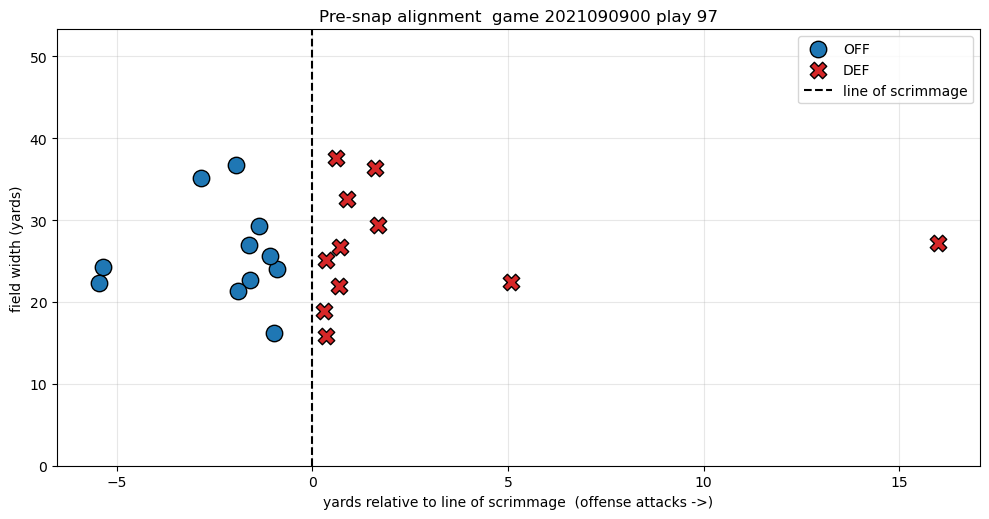

In [27]:
# ---- Visualize one play's pre-snap alignment ------------------------------
def plot_play(gameId, playId):
    play = presnap[(presnap.gameId == gameId) & (presnap.playId == playId)]
    if play.empty:
        print("Play not found in the loaded set."); return
    fig, ax = plt.subplots(figsize=(10, 5.3))
    for side, color, marker in [("OFF", "tab:blue", "o"), ("DEF", "tab:red", "X")]:
        s = play[play.side == side]
        ax.scatter(s.los_offset, s.y_norm, c=color, s=140, marker=marker,
                   edgecolors="black", label=side, zorder=3)
    ax.axvline(0, ls="--", c="black", lw=1.5, label="line of scrimmage")
    ax.set_xlabel("yards relative to line of scrimmage  (offense attacks ->)")
    ax.set_ylabel("field width (yards)")
    ax.set_ylim(0, 53.3); ax.set_title(f"Pre-snap alignment  game {gameId} play {playId}")
    ax.legend(loc="upper right"); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

# Draw the first available play
first = presnap[["gameId","playId"]].drop_duplicates().iloc[0]
plot_play(int(first.gameId), int(first.playId))


## 4. Defining the defensive formation (from official personnel)

The dataset labels the **offensive** formation but not the defensive one, so we create a `defensiveFormation` feature. Rather than guess it from tracking coordinates, we read it straight from the official **`personnelD`** field in `plays.csv`, which the NFL already provides for every play as text like `"4 DL, 2 LB, 5 DB"`.

That string tells us exactly how many **defensive linemen (DL)**, **linebackers (LB)**, and **defensive backs (DB)** were on the field. We parse those three counts and map the `(DL, LB, DB)` signature to a conventional formation name:

| Name | DL | LB | DB |
|---|---|---|---|
| 4-3 | 4 | 3 | 4 |
| 3-4 | 3 | 4 | 4 |
| Nickel (4-2-5) | 4 | 2 | 5 |
| Nickel (3-3-5) | 3 | 3 | 5 |
| Dime (4-1-6) | 4 | 1 | 6 |
| Dime (3-2-6) | 3 | 2 | 6 |
| 46 | 4 | 4 | 3 |
| Quarter (3-1-7) | 3 | 1 | 7 |

Any signature that is not one of these conventional looks keeps a readable `DL-LB-DB` label (e.g. `2-4-5`), so nothing is silently lost. This is simpler and far more accurate than inferring bands from player depth, because it uses the league's own personnel accounting.

> Note: `personnelD` occasionally includes offensive players lined up on defense (e.g. a fullback as an extra lineman). We account for the standard DL/LB/DB tags and fall back to the raw label when the counts are unusual.

In [28]:
# ---- Read the defensive formation straight from the official personnelD ----
# personnelD looks like "4 DL, 2 LB, 5 DB" (sometimes with extra tags such as
# "1 RB" when an offensive player is on the field). We extract the DL/LB/DB
# counts and name the resulting (DL, LB, DB) signature.

import re

# Conventional (DL, LB, DB) signatures -> formation name.
DEF_NAMES = {
    (4, 3, 4): "4-3",
    (3, 4, 4): "3-4",
    (4, 2, 5): "Nickel (4-2-5)",
    (3, 3, 5): "Nickel (3-3-5)",
    (4, 1, 6): "Dime (4-1-6)",
    (3, 2, 6): "Dime (3-2-6)",
    (4, 4, 3): "46",
    (3, 1, 7): "Quarter (3-1-7)",
}

def parse_personneld(text):
    """Return (DL, LB, DB) counts from a personnelD string, or NaNs if absent."""
    if not isinstance(text, str):
        return (np.nan, np.nan, np.nan)
    def grab(tag):
        m = re.search(rf"(\d+)\s*{tag}", text)
        return int(m.group(1)) if m else 0
    return (grab("DL"), grab("LB"), grab("DB"))

def name_defense(dl, lb, db):
    """Map a (DL, LB, DB) signature to a conventional name, else 'DL-LB-DB'."""
    if any(pd.isna(v) for v in (dl, lb, db)):
        return "Unknown"
    sig = (int(dl), int(lb), int(db))
    return DEF_NAMES.get(sig, f"{sig[0]}-{sig[1]}-{sig[2]}")

# Build the per-play defensive formation table directly from plays.
_pd = plays[["gameId", "playId", "personnelD"]].copy()
_counts = _pd["personnelD"].map(parse_personneld)
_pd["DL"] = _counts.map(lambda t: t[0])
_pd["LB"] = _counts.map(lambda t: t[1])
_pd["DB"] = _counts.map(lambda t: t[2])
_pd["defensiveFormation"] = [name_defense(dl, lb, db)
                             for dl, lb, db in zip(_pd.DL, _pd.LB, _pd.DB)]

def_form = _pd[["gameId", "playId", "DL", "LB", "DB", "defensiveFormation"]]

print("Defensive formation distribution (from personnelD):")
print(def_form["defensiveFormation"].value_counts())
def_form.head()

Defensive formation distribution (from personnelD):
defensiveFormation
Nickel (4-2-5)     1254
2-4-5               732
Nickel (3-3-5)      600
4-3                 366
2-3-6               333
3-4                 249
Dime (3-2-6)        210
Dime (4-1-6)        197
1-4-6                80
1-5-5                56
5-2-4                47
5-1-5                12
2-5-4                11
2-2-7                 8
1-3-7                 8
Quarter (3-1-7)       7
46                    4
0-3-8                 4
5-3-3                 3
0-5-6                 2
6-1-4                 2
6-3-2                 2
Unknown               1
4-6-1                 1
Name: count, dtype: int64


,gameId,playId,DL,LB,DB,defensiveFormation
0,2021090900,97,4.0,2.0,5.0,Nickel (4-2-5)
1,2021090900,137,4.0,4.0,3.0,46
2,2021090900,187,3.0,3.0,5.0,Nickel (3-3-5)
3,2021090900,282,4.0,3.0,4.0,4-3
4,2021090900,349,3.0,4.0,4.0,3-4


In [30]:
"""# ---- Apply the banding to every defensive player, per play ----------------
defn = presnap[presnap.side == "DEF"].merge(
    pff[["gameId","playId","nflId","pff_positionLinedUp","pff_role"]],
    on=["gameId","playId","nflId"], how="left")

defn["band"] = [reconcile(pos, dep) for pos, dep
                in zip(defn["pff_positionLinedUp"], defn["los_offset"])]

# Count the (DL, LB, DB) signature per play and match a template.
sig = (defn.groupby(["gameId","playId","band"]).size()
            .unstack(fill_value=0)
            .reindex(columns=["DL","LB","DB"], fill_value=0))
sig["signature"] = list(zip(sig["DL"], sig["LB"], sig["DB"]))
sig["defensiveFormation"] = sig["signature"].map(match_template)
def_form = sig.reset_index()[["gameId","playId","DL","LB","DB","defensiveFormation"]]

print("Derived defensive formation distribution:")
print(def_form["defensiveFormation"].value_counts())
def_form.head()"""


'# ---- Apply the banding to every defensive player, per play ----------------\ndefn = presnap[presnap.side == "DEF"].merge(\n    pff[["gameId","playId","nflId","pff_positionLinedUp","pff_role"]],\n    on=["gameId","playId","nflId"], how="left")\n\ndefn["band"] = [reconcile(pos, dep) for pos, dep\n                in zip(defn["pff_positionLinedUp"], defn["los_offset"])]\n\n# Count the (DL, LB, DB) signature per play and match a template.\nsig = (defn.groupby(["gameId","playId","band"]).size()\n            .unstack(fill_value=0)\n            .reindex(columns=["DL","LB","DB"], fill_value=0))\nsig["signature"] = list(zip(sig["DL"], sig["LB"], sig["DB"]))\nsig["defensiveFormation"] = sig["signature"].map(match_template)\ndef_form = sig.reset_index()[["gameId","playId","DL","LB","DB","defensiveFormation"]]\n\nprint("Derived defensive formation distribution:")\nprint(def_form["defensiveFormation"].value_counts())\ndef_form.head()'

### How much of the data has a usable defensive formation?

Because we now take the label directly from the official `personnelD` field, there is no heuristic to validate. Instead we check **coverage**: how many plays actually carry a `personnelD` value, and how the named formations break down. Plays without it (rare) fall through as `Unknown` and are handled by the support threshold later.

In [31]:
# ---- Coverage report for the derived defensive formation ------------------
have_ref = def_form["DL"].notna()
total = len(def_form)
print(f"Plays with a personnelD value: {int(have_ref.sum())} / {total} "
      f"({have_ref.mean():.1%})")

named = def_form.loc[have_ref, "defensiveFormation"]
conventional = named.isin(list(DEF_NAMES.values()))
print(f"Named with a conventional label: {conventional.mean():.1%}")
print("\nTop defensive formations:")
print(named.value_counts().head(10))

Plays with a personnelD value: 4188 / 4189 (100.0%)
Named with a conventional label: 68.9%

Top defensive formations:
defensiveFormation
Nickel (4-2-5)    1254
2-4-5              732
Nickel (3-3-5)     600
4-3                366
2-3-6              333
3-4                249
Dime (3-2-6)       210
Dime (4-1-6)       197
1-4-6               80
1-5-5               56
Name: count, dtype: int64


## 5. Feature assembly

The model input is the pre-snap geometry: the normalized `(x, y)` of all 22 players, plus the offensive and derived defensive formation and a little game context.

**One subtlety that matters a lot: player ordering.** Tracking rows arrive in no meaningful order. If we just dumped 22 points into a vector, "slot 3" could be a tackle on one play and a receiver on the next, and the model would learn noise. So we impose a **canonical order**: within each team we sort players by depth off the line, then left-to-right across the field. Now each slot consistently refers to a comparable role, which is what lets the model learn real spatial patterns.

We attach the yards-gained label (`playResult`) and keep a few optional context fields (`down`, `yardsToGo`, `defendersInBox`).


In [32]:
# ---- Build one fixed-length feature row per play --------------------------
def ordered_xy(group):
    # canonical order: by depth off LOS, then across the field (y)
    g = group.sort_values(["los_offset", "y_norm"]).head(11)
    return np.array(g[["los_offset", "y_norm"]]).flatten()

rows = []
for (gid, pid), grp in presnap.groupby(["gameId", "playId"]):
    off = ordered_xy(grp[grp.side == "OFF"])
    de  = ordered_xy(grp[grp.side == "DEF"])
    if len(off) != 22 or len(de) != 22:
        continue
    rows.append({"gameId": gid, "playId": pid,
                 **{f"off_{i}": v for i, v in enumerate(off)},
                 **{f"def_{i}": v for i, v in enumerate(de)}})

feat = pd.DataFrame(rows)

# Attach labels + context + derived defensive formation.
meta = plays[["gameId","playId","offenseFormation",LABEL_FIELD,
              "down","yardsToGo","defendersInBox"]]
feat = (feat.merge(meta, on=["gameId","playId"], how="inner")
            .merge(def_form[["gameId","playId","defensiveFormation"]],
                   on=["gameId","playId"], how="left"))
feat = feat.dropna(subset=["offenseFormation", LABEL_FIELD])
print(f"Assembled feature table: {feat.shape[0]} plays x {feat.shape[1]} columns")
feat.head()


Assembled feature table: 4172 plays x 52 columns


,gameId,playId,off_0,off_1,off_2,off_3,off_4,off_5,off_6,off_7,...,def_18,def_19,def_20,def_21,offenseFormation,playResult,down,yardsToGo,defendersInBox,defensiveFormation
0,2021090900,97,-5.45,22.27,-5.36,24.26,-2.84,35.09,-1.96,36.77,...,5.07,22.41,15.99,27.18,SHOTGUN,0,3,2,6.0,Nickel (4-2-5)
1,2021090900,137,-5.19,29.66,-2.11,9.23,-1.98,17.86,-1.86,26.69,...,9.14,9.55,16.27,28.98,EMPTY,28,1,10,6.0,46
2,2021090900,187,-5.26,26.84,-5.00,23.92,-2.72,15.87,-2.27,24.09,...,7.59,31.98,9.63,26.76,SHOTGUN,5,2,6,6.0,Nickel (3-3-5)
3,2021090900,282,-8.12,23.24,-2.14,36.30,-1.72,23.18,-1.64,17.91,...,11.52,21.51,12.76,30.20,SINGLEBACK,0,1,10,6.0,4-3
4,2021090900,349,-4.82,23.21,-4.06,24.99,-2.76,14.57,-1.88,35.23,...,8.85,42.79,13.08,26.81,SHOTGUN,0,3,15,7.0,3-4


## 6. The 20-datapoint rule

Some formations barely appear (WILDCAT shows up a couple of times in the full dataset). A model trained on a handful of plays is not trustworthy, so we **hard-exclude** any offensive or defensive formations with fewer than `MIN_SUPPORT` (20) plays. Those formations never enter the dropdown, training, or prediction Ã¢â‚¬â€ but we report what we dropped and why.


In [33]:
# ---- Apply the hard-exclusion floor to offensive formations ---------------
off_counts = feat["offenseFormation"].value_counts()
off_selectable = sorted([f for f, n in off_counts.items() if n >= MIN_SUPPORT])
off_excluded = {f: int(n) for f, n in off_counts.items() if n < MIN_SUPPORT}

print("Selectable offensive formations (>= %d plays):" % MIN_SUPPORT)
for f in off_selectable:
    print(f"  {f:<12} {int(off_counts[f]):>5} plays")
print("\nExcluded offensive (too few plays):", off_excluded if off_excluded else "none")

feat = feat[feat["offenseFormation"].isin(off_selectable)].copy()

# ---- Apply the hard-exclusion floor to defensive formations ---------------
def_counts = feat["defensiveFormation"].value_counts()
def_selectable = sorted([f for f, n in def_counts.items() if n >= MIN_SUPPORT])
def_excluded = {f: int(n) for f, n in def_counts.items() if n < MIN_SUPPORT}

print("\nSelectable defensive formations (>= %d plays):" % MIN_SUPPORT)
for f in def_selectable:
    print(f"  {f:<12} {int(def_counts[f]):>5} plays")
print("\nExcluded defensive (too few plays):", def_excluded if def_excluded else "none")

feat = feat[feat["defensiveFormation"].isin(def_selectable)].copy()
print(f"\nFeature table after all exclusions: {len(feat)} plays")


Selectable offensive formations (>= 20 plays):
  EMPTY          701 plays
  I_FORM         159 plays
  PISTOL          83 plays
  SHOTGUN       2654 plays
  SINGLEBACK     564 plays

Excluded offensive (too few plays): {'JUMBO': 10, 'WILDCAT': 1}

Selectable defensive formations (>= 20 plays):
  1-4-6           80 plays
  1-5-5           56 plays
  2-3-6          331 plays
  2-4-5          728 plays
  3-4            247 plays
  4-3            361 plays
  5-2-4           45 plays
  Dime (3-2-6)   208 plays
  Dime (4-1-6)   196 plays
  Nickel (3-3-5)   598 plays
  Nickel (4-2-5)  1249 plays

Excluded defensive (too few plays): {'5-1-5': 12, '2-5-4': 11, '2-2-7': 8, '1-3-7': 8, 'Quarter (3-1-7)': 7, '46': 4, '0-3-8': 4, '6-1-4': 2, '0-5-6': 2, '6-3-2': 2, '4-6-1': 1, '5-3-3': 1}

Feature table after all exclusions: 4099 plays


## 7. The yardage distribution model

Here is the heart of the tool. We want a full probability distribution over yards, not a point estimate.

**Approach: discretize, then classify.** We treat each integer-yard outcome as a class and train a gradient-boosted classifier whose predicted class-probabilities *are* the distribution. This handles the real shape of football outcomes Ã¢â‚¬â€ a spike near zero, a long right tail for the occasional big gain, mass in the negatives for sacks Ã¢â‚¬â€ without forcing a symmetric bell curve.

Because the raw yard labels are sparse (we will never see every integer), we **smooth** the predicted probabilities with a small Gaussian kernel across the yard axis and renormalize so they still sum to 1. That spreads a little mass onto nearby yards and gives a sensible, continuous-looking curve.

**Train/test split by game.** We split so that *all plays from a game* land on the same side of the split. If plays from one game appeared in both train and test, the model could memorize game-specific quirks and look better than it really is.

**lightgbm or fallback.** We use LightGBM if available; otherwise scikit-learn's `HistGradientBoostingClassifier`. Both are gradient-boosted trees and both expose `predict_proba`.


In [34]:
# ---- Pick a gradient-boosting backend (lightgbm or sklearn fallback) ------
try:
    from lightgbm import LGBMClassifier
    def make_model():
        return LGBMClassifier(n_estimators=200, num_leaves=31,
                              random_state=SEED, deterministic=True,
                              verbose=-1)
    BACKEND = "lightgbm"
except Exception:
    from sklearn.ensemble import HistGradientBoostingClassifier
    def make_model():
        return HistGradientBoostingClassifier(max_iter=200, random_state=SEED)
    BACKEND = "sklearn HistGradientBoosting"

print("Model backend:", BACKEND)

FEATURE_COLS = ([f"off_{i}" for i in range(22)] +
                [f"def_{i}" for i in range(22)] +
                ["down", "yardsToGo", "defendersInBox"])

def smooth(pmf, sigma=2.0):
    # Gaussian smoothing across the integer-yard axis, then renormalize.
    idx = np.arange(len(pmf))
    out = np.zeros_like(pmf, dtype=float)
    for i in range(len(pmf)):
        w = np.exp(-0.5 * ((idx - i) / sigma) ** 2)
        out[i] = np.sum(pmf * w)
    s = out.sum()
    return out / s if s > 0 else out


Model backend: sklearn HistGradientBoosting


In [35]:
# ---- Game-level split -----------------------------------------------------
uniq_games = feat["gameId"].unique()
rng.shuffle(uniq_games)
n_test = max(1, int(round(0.2 * len(uniq_games))))
test_games = set(uniq_games[:n_test])
train = feat[~feat.gameId.isin(test_games)].copy()
test  = feat[ feat.gameId.isin(test_games)].copy()
print(f"Train plays: {len(train)}  Test plays: {len(test)}  "
      f"(test games: {len(test_games)}/{len(uniq_games)})")

def clip_label(y):
    # map yards into the fixed support range and to a class index
    yc = np.clip(y, YARD_MIN, YARD_MAX).astype(int)
    return yc - YARD_MIN   # 0-based class index

# ---- Train one model per selectable offensive formation -------------------
models = {}
for form in off_selectable:
    sub = train[train.offenseFormation == form]
    if len(sub) < MIN_SUPPORT:
        continue
    X = sub[FEATURE_COLS].fillna(0).values
    y = clip_label(sub[LABEL_FIELD].values)
    m = make_model()
    m.fit(X, y)
    models[form] = m
    print(
        f"  trained {form:<12} on {len(sub):>5} plays "
        f"({len(np.unique(y))} distinct yard outcomes)"
    )

print("\nModels trained:", list(models.keys()))


Train plays: 3298  Test plays: 801  (test games: 12/60)
  trained EMPTY        on   579 plays (59 distinct yard outcomes)
  trained I_FORM       on   116 plays (35 distinct yard outcomes)
  trained PISTOL       on    67 plays (25 distinct yard outcomes)
  trained SHOTGUN      on  2113 plays (72 distinct yard outcomes)
  trained SINGLEBACK   on   423 plays (60 distinct yard outcomes)

Models trained: ['EMPTY', 'I_FORM', 'PISTOL', 'SHOTGUN', 'SINGLEBACK']


In [36]:
# ---- Turn a trained model into a full distribution over YARD_SUPPORT ------
def predict_distribution(form, x_row):
    """Return a probability over every integer yard in YARD_SUPPORT."""
    m = models[form]
    proba = m.predict_proba(x_row.reshape(1, -1))[0]
    # map model classes back onto the full fixed yard axis
    full = np.zeros(len(YARD_SUPPORT), dtype=float)
    for cls, pr in zip(m.classes_, proba):
        full[int(cls)] = pr
    full = smooth(full, sigma=2.0)
    return full

def dist_summary(pmf):
    mean = float(np.sum(YARD_SUPPORT * pmf))
    var  = float(np.sum((YARD_SUPPORT - mean) ** 2 * pmf))
    return mean, np.sqrt(var)

# sanity check: distributions must be valid probabilities
_f = off_selectable[0]
_x = train[train.offenseFormation == _f][FEATURE_COLS].fillna(0).values[0]
_d = predict_distribution(_f, _x)
print(f"Example distribution for {_f}: sum={_d.sum():.4f} (should be ~1.0), "
      f"mean={dist_summary(_d)[0]:.1f} yd, std={dist_summary(_d)[1]:.1f} yd")


Example distribution for EMPTY: sum=1.0000 (should be ~1.0), mean=10.0 yd, std=2.0 yd


## 8. Confidence score

A prediction backed by 2,000 plays deserves more trust than one backed by 35. We attach a confidence score that grows with the supporting sample size `n`:

$$ \text{confidence}(n) = \frac{n}{n + k}, \quad k = 30 $$

With `k` equal to the 30-play floor, a formation sitting exactly at the minimum scores `30/60 = 0.5` Ã¢â‚¬â€ a readable "half-trusted" anchor. More data pushes confidence toward 1; it never exceeds 1 and never decreases as `n` grows.


In [37]:
# ---- Confidence from supporting sample size -------------------------------
def confidence(n, k=MIN_SUPPORT):
    return n / (n + k)

for form in off_selectable:
    n = int((train.offenseFormation == form).sum())
    print(f"  {form:<12} n={n:>5}  confidence={confidence(n):.3f}")


  EMPTY        n=  579  confidence=0.967
  I_FORM       n=  116  confidence=0.853
  PISTOL       n=   67  confidence=0.770
  SHOTGUN      n= 2113  confidence=0.991
  SINGLEBACK   n=  423  confidence=0.955


### Visualizing a predicted distribution

The next cell predicts the yardage distribution for one test play and plots it. The curve shows the probability of each outcome; the dashed line marks the expected (mean) yards; the shaded region to the right of `yardsToGo` is the probability of converting a first down.


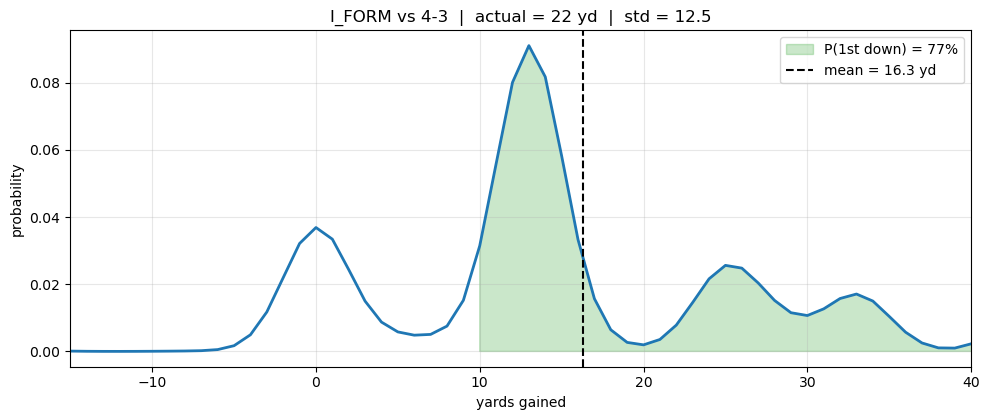

In [38]:
# ---- Plot a predicted distribution for one play ---------------------------
def show_prediction(play_row):
    form = play_row["offenseFormation"]
    if form not in models:
        print("No model for", form); return
    x = play_row[FEATURE_COLS].fillna(0).values.astype(float)
    pmf = predict_distribution(form, x)
    mean, std = dist_summary(pmf)
    ytg = play_row["yardsToGo"]
    p_first = float(pmf[YARD_SUPPORT >= ytg].sum())

    fig, ax = plt.subplots(figsize=(10, 4.3))
    ax.plot(YARD_SUPPORT, pmf, lw=2, color="tab:blue")
    ax.fill_between(YARD_SUPPORT, pmf, where=(YARD_SUPPORT >= ytg),
                    alpha=0.25, color="tab:green",
                    label=f"P(1st down) = {p_first:.0%}")
    ax.axvline(mean, ls="--", color="black", label=f"mean = {mean:.1f} yd")
    ax.set_xlim(-15, 40)
    ax.set_xlabel("yards gained"); ax.set_ylabel("probability")
    ax.set_title(f"{form} vs {play_row.get('defensiveFormation','?')}  |  "
                 f"actual = {int(play_row[LABEL_FIELD])} yd  |  std = {std:.1f}")
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

show_prediction(test.iloc[0])


## 9. Matchup analysis: offense vs each defense

This is the coach-facing payoff. For a selected offensive formation, we break the historical plays down by the **defensive formation** faced and summarize the yardage distribution for each matchup. That reveals which defensive looks tend to give up more or fewer yards against that offense.

Matchups with fewer than `MIN_SUPPORT` plays are excluded (and reported), because a 4-play matchup average is noise. Each surviving matchup carries its own sample size and confidence.


In [39]:
# ---- Empirical matchup table for a chosen offensive formation -------------
def matchup_table(off_formation):
    sub = feat[feat.offenseFormation == off_formation]
    rows = []
    for dform, g in sub.groupby("defensiveFormation"):
        n = len(g)
        rows.append({
            "defensiveFormation": dform,
            "plays": n,
            "mean_yards": round(g[LABEL_FIELD].mean(), 1),
            "std_yards": round(g[LABEL_FIELD].std(ddof=0), 1),
            "confidence": round(confidence(n), 3),
            "included": n >= MIN_SUPPORT,
        })
    tbl = pd.DataFrame(rows).sort_values("mean_yards", ascending=False)
    return tbl

example_form = off_selectable[0]
print(f"Matchups for offensive formation: {example_form}\n")
mt = matchup_table(example_form)
print(mt.to_string(index=False))

inc = mt[mt.included]
if len(inc):
    print(f"\nBest matchup for offense:  {inc.iloc[0].defensiveFormation} "
          f"({inc.iloc[0].mean_yards} yd)")
    print(f"Worst matchup for offense: {inc.iloc[-1].defensiveFormation} "
          f"({inc.iloc[-1].mean_yards} yd)")


Matchups for offensive formation: EMPTY

defensiveFormation  plays  mean_yards  std_yards  confidence  included
             1-5-5      8        11.6       15.9       0.286     False
    Nickel (4-2-5)    227         7.4       10.8       0.919      True
               4-3     40         7.2        8.3       0.667      True
      Dime (3-2-6)     23         6.9        9.3       0.535      True
      Dime (4-1-6)     34         6.9       10.3       0.630      True
             1-4-6     17         6.8       10.1       0.459     False
             2-3-6     66         6.6       12.3       0.767      True
             2-4-5    151         6.5       11.6       0.883      True
             5-2-4      4         5.8        2.9       0.167     False
    Nickel (3-3-5)     89         5.6        8.7       0.817      True
               3-4     37         5.5        6.6       0.649      True

Best matchup for offense:  Nickel (4-2-5) (7.4 yd)
Worst matchup for offense: 3-4 (5.5 yd)


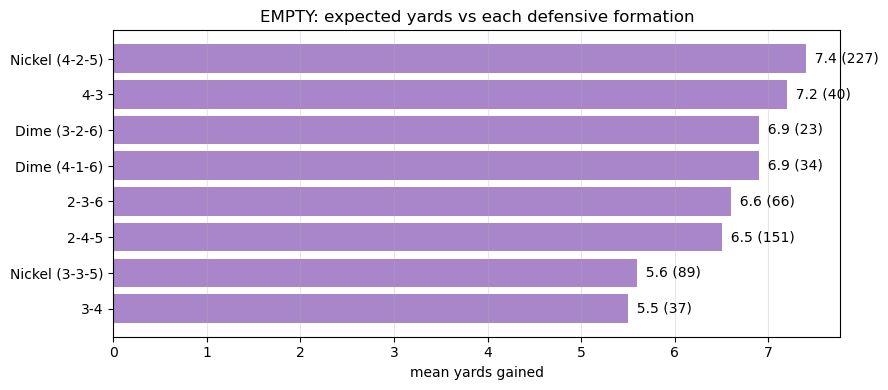

In [40]:
# ---- Plot mean yards by defensive formation for the selected offense ------
inc = mt[mt.included]
if len(inc):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(inc["defensiveFormation"], inc["mean_yards"],
            color="tab:purple", alpha=0.8)
    ax.set_xlabel("mean yards gained"); ax.invert_yaxis()
    ax.set_title(f"{example_form}: expected yards vs each defensive formation")
    for y, (v, n) in enumerate(zip(inc["mean_yards"], inc["plays"])):
        ax.text(v, y, f"  {v} ({n})", va="center")
    ax.grid(alpha=0.3, axis="x"); plt.tight_layout(); plt.show()
else:
    print("No matchups meet the support threshold in this sample. "
          "Try increasing MAX_GAMES.")


## 10. Does the model actually work? Evaluation

A distribution model is judged on whether its probabilities are *honest*, not just whether the mean is close. We use two standard tools:

- **CRPS (Continuous Ranked Probability Score).** It rewards putting probability mass near the true outcome and penalizes being confidently wrong. Lower is better. We compute it on the held-out games.
- **Baseline comparison.** The simplest honest guess is the overall yardage distribution ignoring formation entirely. If our model cannot beat that marginal baseline, the formation information is not helping and we should say so.

CRPS for a discrete distribution is the sum over the yard axis of `(predicted CDF - actual step CDF)^2`.


In [43]:
# ---- CRPS and a formation-agnostic baseline -------------------------------
def crps(pmf, actual):
    cdf_pred = np.cumsum(pmf)
    cdf_true = (YARD_SUPPORT >= np.clip(actual, YARD_MIN, YARD_MAX)).astype(float)
    return float(np.sum((cdf_pred - cdf_true) ** 2))

# Baseline: marginal distribution of yards on the training set.
base_counts = np.zeros(len(YARD_SUPPORT))
for y in clip_label(train[LABEL_FIELD].values):
    base_counts[y] += 1
baseline_pmf = smooth(base_counts / base_counts.sum(), sigma=2.0)

model_scores, base_scores = [], []
for _, row in test.iterrows():
    form = row["offenseFormation"]
    if form not in models:
        continue
    x = row[FEATURE_COLS].fillna(0).values.astype(float)
    pmf = predict_distribution(form, x)
    actual = int(row[LABEL_FIELD])
    model_scores.append(crps(pmf, actual))
    base_scores.append(crps(baseline_pmf, actual))

m_mean, b_mean = np.mean(model_scores), np.mean(base_scores)
print(f"Held-out plays scored: {len(model_scores)}")
print(f"Mean CRPS  model:    {m_mean:.3f}")
print(f"Mean CRPS  baseline: {b_mean:.3f}")
print(f"Improvement over baseline: {b_mean - m_mean:+.3f} "
      f"({'BEATS baseline' if m_mean < b_mean else 'does NOT beat baseline'})")


Held-out plays scored: 801
Mean CRPS  model:    7.027
Mean CRPS  baseline: 5.413
Improvement over baseline: -1.615 (does NOT beat baseline)


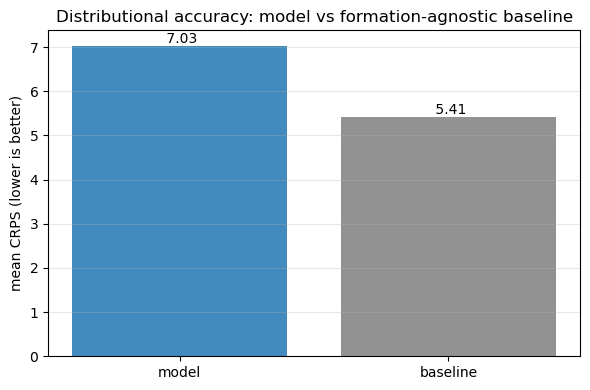

In [44]:
# ---- Compare model vs baseline CRPS visually ------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["model", "baseline"], [m_mean, b_mean],
       color=["tab:blue", "tab:gray"], alpha=0.85)
ax.set_ylabel("mean CRPS (lower is better)")
ax.set_title("Distributional accuracy: model vs formation-agnostic baseline")
for i, v in enumerate([m_mean, b_mean]):
    ax.text(i, v, f" {v:.2f}", ha="center", va="bottom")
ax.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()


## 11. Broadcaster-style snapshot

Finally, the broadcaster view: given a single play, return a compact, graphic-ready summary Ã¢â‚¬â€ expected yards, the spread, the probability of a first down, the formations involved, and the confidence. In a real deployment these numbers would be precomputed so the lookup returns in well under a second.


In [45]:
# ---- One-call broadcaster snapshot for a play -----------------------------
def broadcaster_snapshot(play_row):
    form = play_row["offenseFormation"]
    if form not in models:
        return {"error": f"no model for formation {form}"}
    x = play_row[FEATURE_COLS].fillna(0).values.astype(float)
    pmf = predict_distribution(form, x)
    mean, std = dist_summary(pmf)
    ytg = play_row["yardsToGo"]
    n = int((train.offenseFormation == form).sum())
    return {
        "offensiveFormation": form,
        "defensiveFormation": play_row.get("defensiveFormation", "?"),
        "expected_yards": round(mean, 1),
        "std_yards": round(std, 1),
        "p_first_down": round(float(pmf[YARD_SUPPORT >= ytg].sum()), 2),
        "confidence": round(confidence(n), 2),
        "supporting_plays": n,
        "actual_yards": int(play_row[LABEL_FIELD]),
    }

import json
print(json.dumps(broadcaster_snapshot(test.iloc[0]), indent=2))


{
  "offensiveFormation": "I_FORM",
  "defensiveFormation": "4-3",
  "expected_yards": 16.3,
  "std_yards": 12.5,
  "p_first_down": 0.77,
  "confidence": 0.85,
  "supporting_plays": 116,
  "actual_yards": 22
}


## 12. Where to go next

This notebook is an end-to-end **first pass** that proves the approach runs on real data. Honest next steps:

- **Load all 122 games** (`MAX_GAMES = None`) so sparse formations and matchups clear the 30-play floor and the per-matchup distributions become meaningful.
- **Calibration check.** Add a reliability plot (predicted vs observed cumulative probabilities) to confirm the probabilities are well-calibrated, not just low-CRPS.
- **Tune the defensive banding.** Inspect the `Other/Unknown` plays and the depth thresholds using the `personnelD` cross-check, then adjust.
- **Richer features.** Add player orientation, spacing/gaps between linemen, receiver splits, and `personnelO` as inputs.
- **Harden into modules.** The design document (`.kiro/specs/formation-yardage-distribution/design.md`) lays out the production package and property-based tests; this notebook validates the logic that would move there.

A reminder on scope: this dataset is dropback-oriented, so every number here describes pass-leaning football. Treat the defensive-formation label as a useful approximation, not ground truth, since defenses disguise their looks pre-snap.
